In [1]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.3 GB


In [2]:
from datasets import Dataset

def get_dataset(sentences_txt, sentiments_txt, topics_txt, output_path: str):
    with open(sentences_txt, 'r', encoding='utf-8') as f:
        sentences = [line.strip() for line in f]

    with open(sentiments_txt, 'r', encoding='utf-8') as f:
        sentiments = [int(line.strip()) for line in f]

    with open(topics_txt, 'r', encoding='utf-8') as f:
        topics = [int(line.strip()) for line in f]

    dataset = Dataset.from_dict({
        "sentence": sentences,
        "sentiment": sentiments,
        "topic": topics
    })

    dataset.to_csv(output_path)

    print(f"Shape: {dataset.num_rows} samples")

c:\Users\admin\vnmese-student-feedback-classifier\train_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Note: Use the above function to merge train, validation & test dataset from https://huggingface.co/datasets/uitnlp/vietnamese_students_feedback/blob/main/vietnamese_students_feedback.py

In [3]:
# # Delete old .txt files before running the next line

# get_dataset("sents.txt", "sentiments.txt", "topics.txt", "datasets/train.csv")
# get_dataset("sents.txt", "sentiments.txt", "topics.txt", "datasets/test.csv")
# get_dataset("sents.txt", "sentiments.txt", "topics.txt", "datasets/validation.csv")

In [4]:
train_dataset = Dataset.from_csv("datasets/train.csv")
validation_dataset = Dataset.from_csv("datasets/validation.csv")
test_dataset = Dataset.from_csv("datasets/test.csv")

In [5]:
dataset_dict = {
    "train": train_dataset,
    "validation": validation_dataset,
    "test": test_dataset
}

* Plot label distribution

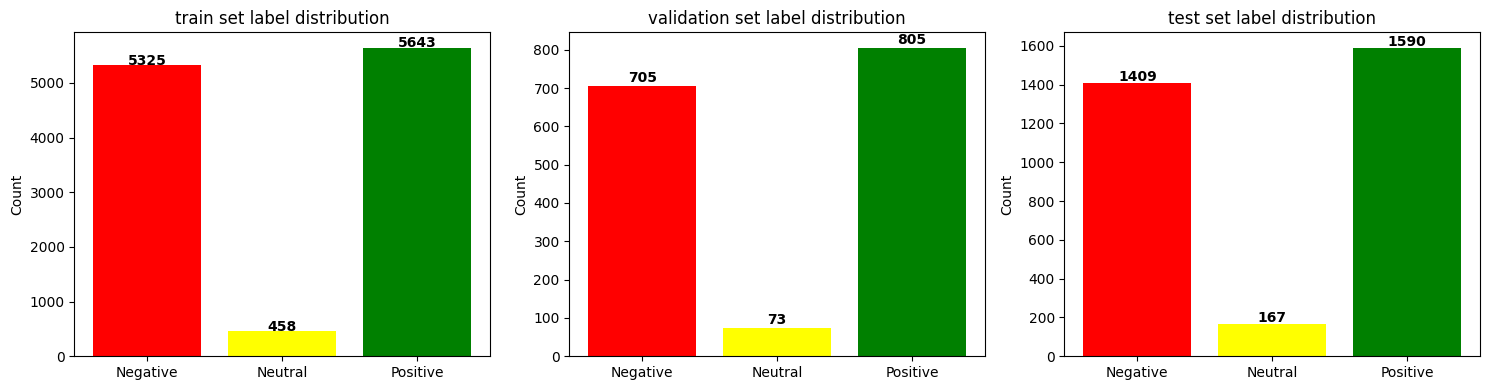

In [6]:
import matplotlib.pyplot as plt

label_names = ["Negative", "Neutral", "Positive"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (split_name, split_dataset) in enumerate(dataset_dict.items()):
    labels = split_dataset["sentiment"]
    label_counts = [labels.count(i) for i in range(3)]
    axes[idx].bar(label_names, label_counts, color=["red", "yellow", "green"])
    axes[idx].set_title(f"{split_name} set label distribution")
    axes[idx].set_ylabel("Count")
    for i, v in enumerate(label_counts):
        axes[idx].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

* Investigate sentence length

In [7]:
import numpy as np

for idx, split_dataset in enumerate([train_dataset, validation_dataset, test_dataset]):
    lengths = [len(s.split()) for s in split_dataset["sentence"]]
    print(f"Sentence length stats for {['Train', 'Validation', 'Test'][idx]} set:")
    print(f"Mean: {np.mean(lengths):.2f}")
    print(f"Std: {np.std(lengths):.2f}")
    print(f"Min: {np.min(lengths)}")
    print(f"Max: {np.max(lengths)}")

Sentence length stats for Train set:
Mean: 14.31
Std: 10.09
Min: 2
Max: 159
Sentence length stats for Validation set:
Mean: 13.67
Std: 9.91
Min: 2
Max: 161
Sentence length stats for Test set:
Mean: 14.22
Std: 10.24
Min: 2
Max: 98


C:\Users\admin\AppData\Local\Temp\ipykernel_24796\2856291450.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Split", y="Sentence Length", data=df, palette="Set2")


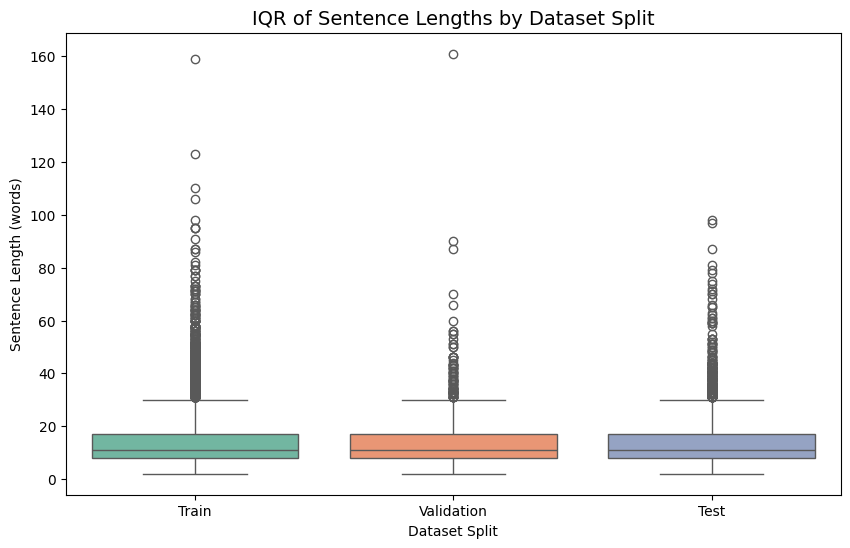

In [8]:
import pandas as pd
import seaborn as sns

all_lengths = []
all_splits = []

for split_name, split_dataset in dataset_dict.items():
    lengths = [len(s.split()) for s in split_dataset["sentence"]]
    all_lengths.extend(lengths)
    all_splits.extend([split_name.capitalize()]*len(lengths))

df = pd.DataFrame({
    "Split": all_splits,
    "Sentence Length": all_lengths
})

plt.figure(figsize=(10, 6))
sns.boxplot(x="Split", y="Sentence Length", data=df, palette="Set2")
plt.title("IQR of Sentence Lengths by Dataset Split", fontsize=14)
plt.xlabel("Dataset Split")
plt.ylabel("Sentence Length (words)")
plt.show()


In [9]:
# View some examples
for label_id, label_name in enumerate(label_names):
    samples = [x for x in train_dataset if x["sentiment"] == label_id][:2]
    print(f"\n{'='*50}")
    print(f"📌 {label_name.upper()}")
    for s in samples:
        print(f"  → {s['sentence']}")


📌 NEGATIVE
  → đi học đầy đủ full điểm chuyên cần .
  → chưa áp dụng công nghệ thông tin và các thiết bị hỗ trợ cho việc giảng dạy .

📌 NEUTRAL
  → em sẽ nợ môn này , nhưng em sẽ học lại ở các học kỳ kế tiếp .
  → đang dạy thầy wzjwz208 đi qua nước ngoài giữa chừng , thầy wzjwz209 dạy thay .

📌 POSITIVE
  → slide giáo trình đầy đủ .
  → nhiệt tình giảng dạy , gần gũi với sinh viên .


# Tokenization with PhoBERT

In [10]:
MODEL_NAME = "vinai/phobert-base"
MAX_LENGTH = 128
NUM_LABELS = 3

In [11]:
from transformers import AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [12]:
sample_text = "Thầy dạy rất nhiệt tình, dễ hiểu và thân thiện với sinh viên."
tokens = tokenizer(sample_text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH)

print("Input text:", sample_text)
print("\nToken IDs:", tokens["input_ids"][0].tolist())
print("Attention Mask:", tokens["attention_mask"][0].tolist())
print("\nDecoded tokens:")
for tid in tokens["input_ids"][0]:
    print(f"  {tid.item():6d} → '{tokenizer.decode([tid])}'")

Input text: Thầy dạy rất nhiệt tình, dễ hiểu và thân thiện với sinh viên.

Token IDs: [0, 5005, 940, 59, 2515, 33227, 2008, 4, 592, 563, 6, 1182, 5320, 15, 418, 34946, 10557, 2]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Decoded tokens:
       0 → '<s>'
    5005 → 'Thầy'
     940 → 'dạy'
      59 → 'rất'
    2515 → 'nhiệt'
   33227 → 'tì@@'
    2008 → 'nh@@'
       4 → ','
     592 → 'dễ'
     563 → 'hiểu'
       6 → 'và'
    1182 → 'thân'
    5320 → 'thiện'
      15 → 'với'
     418 → 'sinh'
   34946 → 'viê@@'
   10557 → 'n.'
       2 → '</s>'


In [13]:
train_dataset = train_dataset.rename_column("sentiment", "labels")
validation_dataset = validation_dataset.rename_column("sentiment", "labels")
test_dataset = test_dataset.rename_column("sentiment", "labels")

In [14]:
train_dataset.features

{'sentence': Value('large_string'),
 'labels': Value('int64'),
 'topic': Value('int64')}

In [15]:
def tokenize(batch):
    return tokenizer(
        batch["sentence"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    )

tokenized_train = train_dataset.map(tokenize, batched=True, remove_columns=["sentence"])
tokenized_train.set_format("torch")

tokenized_val = validation_dataset.map(tokenize, batched=True, remove_columns=["sentence"])
tokenized_val.set_format("torch")

tokenized_test = test_dataset.map(tokenize, batched=True, remove_columns=["sentence"])
tokenized_test.set_format("torch")

In [16]:
tokenized_train.features

{'labels': Value('int64'),
 'topic': Value('int64'),
 'input_ids': List(Value('int32')),
 'attention_mask': List(Value('int8'))}

# Load phoBERT

In [17]:
from transformers import AutoModelForSequenceClassification


base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={0: "Negative", 1: "Neutral", 2: "Positive"},
    label2id={"Negative": 0, "Neutral": 1, "Positive": 2}
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 26218.56it/s]
RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok i

In [18]:
total_params = sum(p.numel() for p in base_model.parameters())
print(f"Total parameters in the model: {total_params:,}")

Total parameters in the model: 135,000,579


# Add LoRA

In [19]:
from peft import LoraConfig, TaskType, get_peft_model


lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "key", "value", "dense"],
    bias="none"
)

peft_model = get_peft_model(base_model, lora_config)
peft_model.print_trainable_parameters()

trainable params: 1,920,003 || all params: 136,920,582 || trainable%: 1.4023


# Training with LoRA

In [20]:
import evaluate


accuracy = evaluate.load("accuracy")
f1_score = evaluate.load("f1")

def compute_metrics(logits_and_labels):
    logits, labels = logits_and_labels
    predictions = np.argmax(logits, axis=-1)
    accuracy_metric = accuracy.compute(predictions=predictions, references=labels)
    f1_metric = f1_score.compute(predictions=predictions, references=labels, average="weighted")
    return {
        "accuracy": accuracy_metric["accuracy"], 
        "f1_weighted": f1_metric["f1"]
        }

In [21]:
from transformers import TrainingArguments


train_args = TrainingArguments(
    output_dir="./phobert-lora",
    
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    
    report_to="none",
    
    # Mixed precision if GPU available
    fp16=torch.cuda.is_available(),
    
    seed=42
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [22]:
from transformers import DataCollatorWithPadding, Trainer


data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=peft_model,
    args=train_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [23]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,No log,0.239376,0.929880,0.924615
2,0.349061,0.208849,0.934934,0.933799
3,0.184990,0.209407,0.941251,0.939026
4,0.184990,0.218571,0.943146,0.939627
5,0.139496,0.218525,0.945673,0.943271


# Test on test dataset

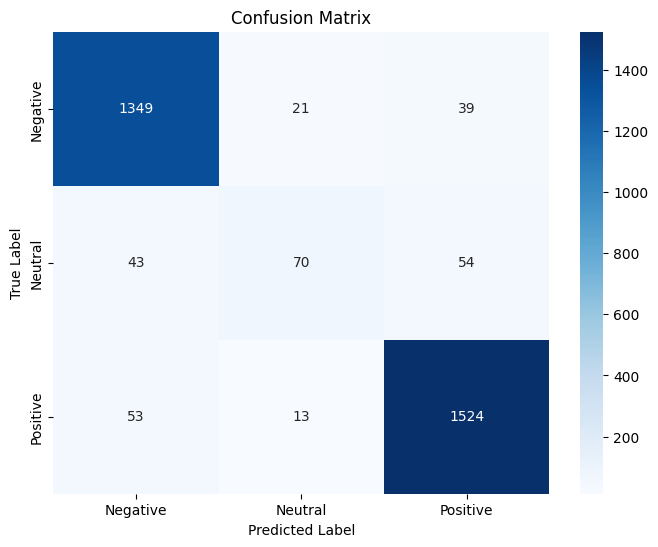

In [24]:
from sklearn.metrics import confusion_matrix

prediction_outputs = trainer.predict(tokenized_test)
predictions = np.argmax(prediction_outputs.predictions, axis=-1)
true_labels = prediction_outputs.label_ids

confusion_matrix = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [25]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=label_names))

Classification Report:

              precision    recall  f1-score   support

    Negative       0.93      0.96      0.95      1409
     Neutral       0.67      0.42      0.52       167
    Positive       0.94      0.96      0.95      1590

    accuracy                           0.93      3166
   macro avg       0.85      0.78      0.80      3166
weighted avg       0.92      0.93      0.93      3166



# Save model

In [26]:
SAVE_PATH = "./phobert-lora-final"
peft_model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

# Compare size of LoRA adapter vs full model
import os
def get_dir_size(path):
    total = sum(os.path.getsize(os.path.join(dp, f)) 
                for dp, _, filenames in os.walk(path) 
                for f in filenames)
    return total / 1e6  # MB

print(f"✅ Model saved to: {SAVE_PATH}")
print(f"   LoRA adapter size: ~{get_dir_size(SAVE_PATH):.1f} MB")

✅ Model saved to: ./phobert-lora-final
   LoRA adapter size: ~9.7 MB


# Merge LoRA weights & export ONNX

In [27]:
LORA_PATH = "./phobert-lora-final"
MERGE_PATH = "./phobert-merged"
ONNX_PATH = "./phobert-merged/model.onnx"
ONNX_DATA_PATH = "./phobert-merged/model.onnx.data"
device = "cpu"

Step 1: Load base model & LoRA adapter

In [28]:
from peft import PeftModel
from transformers import AutoModelForSequenceClassification, AutoTokenizer


base_model = AutoModelForSequenceClassification.from_pretrained(LORA_PATH, num_labels=NUM_LABELS)
tokenizer = AutoTokenizer.from_pretrained(LORA_PATH)

peft_model = PeftModel.from_pretrained(base_model, LORA_PATH)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 36811.81it/s]
RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok i

Step 2: Merge LoRA into base weights & save merge model

In [30]:
merged_model = peft_model.merge_and_unload()
merged_model.eval()

os.makedirs(MERGE_PATH, exist_ok=True)
merged_model._hf_peft_config_loaded = False

merged_model.save_pretrained(
    MERGE_PATH,
)
tokenizer.save_pretrained(MERGE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:06<00:00,  6.50s/it]


('./phobert-merged\\tokenizer_config.json',
 './phobert-merged\\vocab.txt',
 './phobert-merged\\bpe.codes',
 './phobert-merged\\added_tokens.json')

Step 3: Create dummy inputs for tracing

In [31]:
dummy_texts = [
    "Thầy dạy rất hay và nhiệt tình.",
    "Môn học khá nhàm chán và khó hiểu.",
]

dummy_inputs = tokenizer(
    dummy_texts,
    return_tensors="pt",
    truncation=True,
    max_length=MAX_LENGTH,
    padding="max_length"
)

input_ids = dummy_inputs["input_ids"]
attention_mask = dummy_inputs["attention_mask"]

Step 4: Export to ONNX

In [32]:
torch.onnx.export(
    merged_model,
    args=(input_ids, attention_mask),
    f=ONNX_PATH,
    input_names=["input_ids", "attention_mask"],
    output_names=["logits"],
    dynamic_axes={
        "input_ids": {0: "batch_size", 1: "sequence_length"},
        "attention_mask": {0: "batch_size", 1: "sequence_length"},
        "logits": {0: "batch_size"}
    },
    opset_version=14,
    do_constant_folding=True
)

C:\Users\admin\AppData\Local\Temp\ipykernel_24796\3775887331.py:1: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0316 07:31:40.172000 24796 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0316 07:31:41.943000 24796 Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0316 07:31:41.946000 

[torch.onnx] Obtain model graph for `RobertaForSequenceClassification([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `RobertaForSequenceClassification([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


c:\Users\admin\vnmese-student-feedback-classifier\train_env\Lib\site-packages\torch\onnx\_internal\exporter\_onnx_program.py:460: UserWarning: # The axis name: sequence_length will not be used, since it shares the same shape constraints with another axis: sequence_length.
  rename_mapping = _dynamic_shapes.create_rename_mapping(
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 14).
Failed to convert the model to the target version 14 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\admin\vnmese-student-feedback-classifier\train_env\Lib\site-packages\onnxscript\version_converter\__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\admin\vnmese-student-feedback-classifier\train_env\Lib\site-packages\onnxscript\version_co

[torch.onnx] Translate the graph into ONNX... ✅
Applied 113 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input_ids"<INT64,[batch_size,sequence_length]>,
                %"attention_mask"<INT64,[batch_size,sequence_length]>
            ),
            outputs=(
                %"logits"<FLOAT,[batch_size,3]>
            ),
            initializers=(
                %"roberta.embeddings.token_type_embeddings.weight"<FLOAT,[1,768]>{TorchTensor(...)},
                %"roberta.embeddings.LayerNorm.weight"<FLOAT,[768]>{TorchTensor(...)},
                %"roberta.embeddings.LayerNorm.bias"<FLOAT,[768]>{TorchTensor(...)},
                %"roberta.encoder.layer.0.attention.self.query.bias"<FLOAT,[768]>{TorchTensor(...)},
                %"roberta.encoder.layer.0.attention.